In [101]:
import sys
import os
import matplotlib.pyplot as plt
import networkx as nx

# Add the parent directory to the path to import from src
sys.path.append(os.path.abspath(".."))
from concept_creator.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"
session_id = "6_2"
concept_name = session_id



In [102]:
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)
concept_id, concept_graph = service.create_concept_incrementally(
    session_id, concept_name
)

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.critical_point_concept_service:Creating concept for session 6_2 using Critical Point approach.
INFO:root:Getting image IDs for session 6_2
INFO:concept_creator.critical_point_concept_service:Initialized concept with graph from image b0a6d69a-f791-41e4-ba09-f6aa539a2b9b. Nodes: 14
INFO:concept_creator.critical_point_concept_service:Processing image 2/2: 250976bf-ec1a-403d-8dcd-2060cb28736e
INFO:concept_creator.critical_point_concept_service:Updated concept after image 250976bf-ec1a-403d-8dcd-2060cb28736e. Nodes: 10


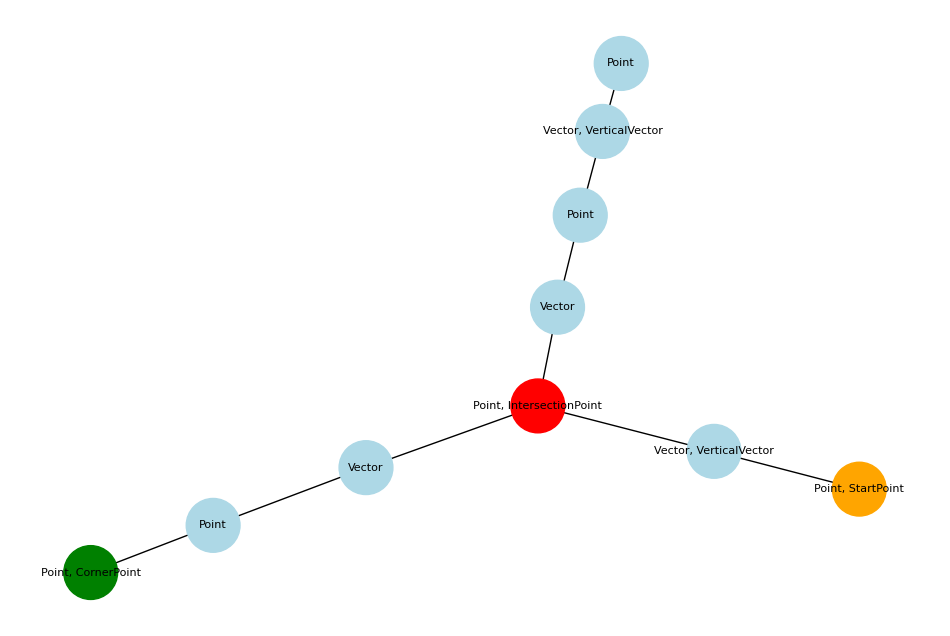

In [103]:
# Create a new figure
plt.figure(figsize=(12, 8))

node_to_color = {
    "IntersectionPoint": "red",
    "CornerPoint": "green",
    "EndPoint": "blue",
    "QuadrantChangePoint": "purple",
    "StartPoint": "orange"
}

# Get node colors based on node labels
node_colors = []
labels_for_nodes = {}

for node in concept_graph.nodes():
    # Get labels from node attributes - try different ways to access labels
    node_data = concept_graph.nodes[node]
    
    # First, try to get labels as a direct attribute
    labels = node_data.get('labels', [])
    
    # If labels is empty, try to get them from node_labels attribute
    if not labels and 'node_labels' in node_data:
        labels = node_data['node_labels']
    
    # If still empty, check if any attribute has 'label' in its name
    if not labels:
        for key in node_data:
            if 'label' in key.lower() and node_data[key]:
                if isinstance(node_data[key], list):
                    labels = node_data[key]
                else:
                    labels = [str(node_data[key])]
                break
    
    # If everything fails, use a default label
    if not labels:
        labels = ["Point"]
    
    # Store labels for node labeling
    labels_for_nodes[node] = ', '.join(str(label) for label in labels) if labels else str(node)
    
    # Check if any label matches our color mapping
    color = 'lightblue'  # Default color
    for label in labels:
        label_str = str(label)  # Convert to string if it's not already
        if label_str in node_to_color:
            color = node_to_color[label_str]
            break
    
    node_colors.append(color)

# Draw the graph with explicit node_color parameter
pos = nx.spring_layout(concept_graph)  # Calculate positions
nx.draw_networkx_nodes(concept_graph, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_edges(concept_graph, pos)
nx.draw_networkx_labels(concept_graph, pos, labels=labels_for_nodes, font_size=8)
plt.axis('off')
plt.show()

In [104]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

Node 4:95f7de00-19a5-43d7-b929-cea0efad5c70:13694: {'labels': ['Point', 'StartPoint'], 'normalized_x': 0.1, 'session_id': '6_2', 'contour_type': 'OPEN', 'y': {'min': 14.758670006901085, 'max': 26.528127984040598, 'type': 'range', 'center': 20.643398995470843}, 'vectors_count': 7, 'monotony': 'NON_MONOTONIC', 'relative_distance': {'min': 0.3, 'max': 0.5, 'type': 'range', 'center': 0.4}, 'cycle_count': 1, 'segments': ['top', 'center_vertical'], 'endpoints_count': 0, 'intersection_points_count': 1, 'normalized_y': {'min': -0.7, 'max': -0.5, 'type': 'range', 'center': -0.5999999999999999}, 'corner_points_count': {'min': 2, 'max': 3, 'type': 'range', 'center': 2.5}, 'x': {'min': 54.81897586857585, 'max': 57.088779886289736, 'type': 'range', 'center': 55.953877877432795}, 'quadrant_change_count': {'min': 4, 'max': 5, 'type': 'range', 'center': 4.5}}
Node 4:95f7de00-19a5-43d7-b929-cea0efad5c70:42: {'labels': ['Vector', 'VerticalVector'], 'normalized_x': -0.1, 'vectors_count': 7, 'endpoints_co